In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d
%matplotlib inline
from ipywidgets import interact, fixed
import ipywidgets as widgets
from numba import njit, prange
import pickle
from typing import List, Tuple, Callable, Any

from utils import MovingFunctionCalculator
from utils import Analytical
from utils import Plotter

In [2]:
@njit
def calc_propensities(grid:np.ndarray[Any, np.dtype[np.float64]], kon:float, koff, kstep):
    n_on = np.sum(grid==0)
    n_off = np.sum(grid)
    n_step = len(np.where((grid[1:]==0)&(grid[:-1]==1))[0])

    aon = n_on*kon
    aoff = n_off*koff
    astep = n_step*kstep

    return np.array([aon, aoff, astep])

In [3]:
@njit
def bind_kinesin(grid: np.ndarray[Any, np.dtype[np.float64]]) -> None:
    sides = np.where(grid==0)[0]
    n_on = len(sides)
    side_idx = np.random.randint(n_on)
    grid[sides[side_idx]] += 1

@njit
def unbind_kinesin(grid: np.ndarray[Any, np.dtype[np.float64]]) -> None:
    sides = np.where(grid==1)[0]
    n_off = len(sides)
    side_idx = np.random.randint(n_off)
    grid[sides[side_idx]] -= 1

@njit
def move_kinesin_w_fall(grid: np.ndarray[Any, np.dtype[np.float64]]) -> None:
    sides = np.where((grid[1:]==0)&(grid[:-1]==1))[0]
    n_step = len(sides)
    side_idx = np.random.randint(n_step)
    grid[sides[side_idx]] -= 1
    if sides[side_idx] <= len(grid)-1:
        grid[sides[side_idx]+1] += 1


In [4]:
@njit
def step(grid, kon, koff, kstep)->Tuple[float, int]:
    r1 = np.random.uniform()
    r2 = np.random.uniform()

    A = calc_propensities(grid, kon, koff, kstep)
    R_tot = np.sum(A)
    
    A_normalised = np.cumsum(A)/R_tot

    dt = (1/R_tot) * np.log(1/r1)
    idx = np.argwhere(A_normalised>r2)[0][0]


    return dt, int(idx)

In [5]:
@njit
def simulation(L, T, kon, koff, kstep):
    time = 0.0
    block = 0
    period = 0.1
    next_write_time = period
    blocks = int(T/period)

    grid:np.ndarray[Any, np.dtype[np.float64]] = np.zeros(L)

    DATA = np.zeros((blocks, L))
    TIMES= np.zeros(blocks)

    while time<T:
        dt, idx = step(grid, kon, koff, kstep)
        time+= dt      
        if idx==0:
            bind_kinesin(grid)
        elif idx==1:
            unbind_kinesin(grid)
        else:
            move_kinesin_w_fall(grid)
            
        if next_write_time<time:
            DATA[block,:] = grid
            TIMES[block] = time
            block+=1
            next_write_time+=period

    return DATA[:block], TIMES[:block]

In [6]:
@njit(parallel=True)
def multiple_SIMS_last(num, L, T, kon, koff, kstep):

    LAST_FRAMES = np.zeros((num, L))
    for i in prange(num):
        DATA, TIMES = simulation(L, T, kon, koff, kstep)
        LAST_FRAMES[i,:]=DATA[-1,:]
    return LAST_FRAMES

In [10]:
L = 400
T = 200
koff = 1
kon = 1
kstep = 100

options={'L':L, 'T':T, 'koff':koff, 'kon':kon, 'kstep':kstep}

In [12]:
res = multiple_SIMS_last(100, L, T, kon, koff, kstep)

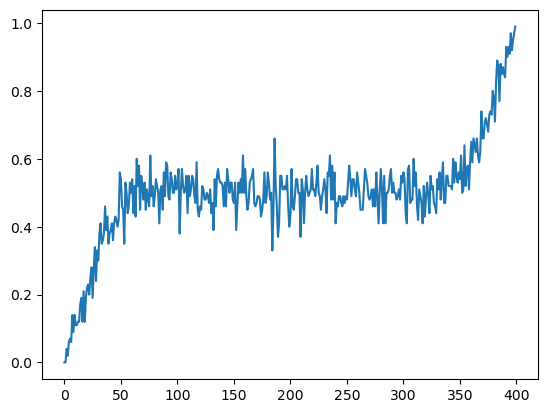

In [13]:
plt.plot(np.mean(res, axis = 0))

In [20]:
np.mean(res, axis = 0)[-5:]

array([0.14, 0.1 , 0.18, 0.22, 0.5 ])

In [30]:
res2 = multiple_SIMS_last(1000, L, T, kon, koff, 100)

In [33]:
res3 = multiple_SIMS_last(1000, L, T, kon, koff, 0)

In [39]:
res4 = multiple_SIMS_last(1000, L, T, 1, 0.1, 0)

In [1]:
import pickle

with open('nice_parabola', 'rb') as f:
    res = pickle.load(f)

In [4]:
mean = np.mean(res, axis=0)
var = np.var(res, axis=0)

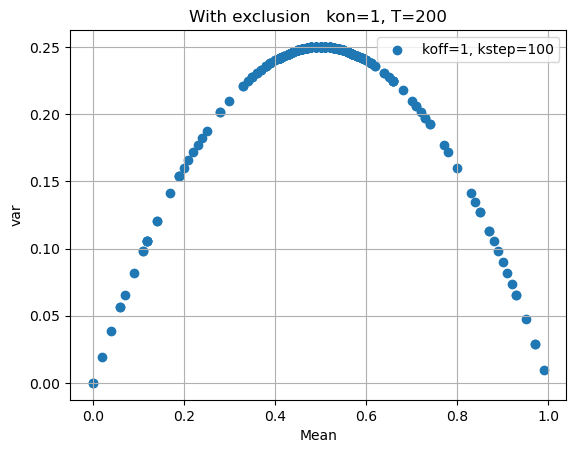

In [7]:
plt.scatter(mean, var, label="koff=1, kstep=100")

plt.legend()
plt.title("With exclusion   kon=1, T=200")
plt.xlabel("Mean")
plt.ylabel("var")
plt.grid()
plt.savefig("var_mean.png")

In [16]:
import pickle

with open('nice_parabola', 'wb') as f:
    pickle.dump(res, f)

In [40]:
mean4 = np.mean(res4, axis=0)
var4 = np.var(res4, axis=0)

In [27]:
mean = np.mean(res, axis=0)
var = np.var(res, axis=0)

mean2 = np.mean(res2, axis=0)
var2 = np.var(res2, axis=0)

mean3 = np.mean(res3, axis=0)
var3 = np.var(res3, axis=0)

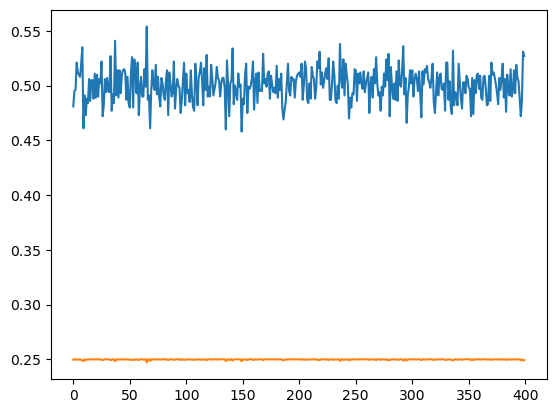

In [35]:
plt.plot(mean3)
plt.plot(var3)

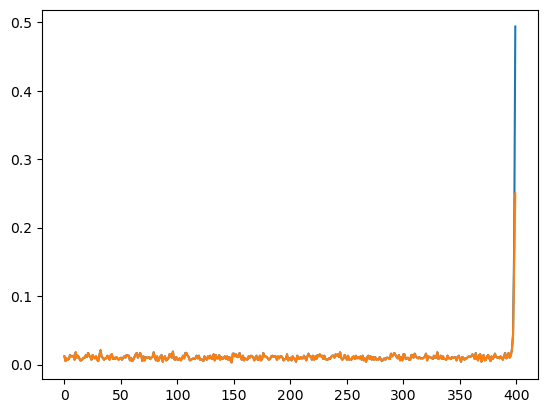

In [32]:
plt.plot(mean2)
plt.plot(var2)

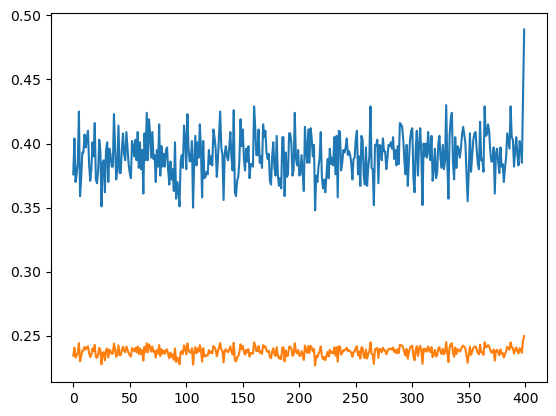

In [28]:
plt.plot(mean)
plt.plot(var)

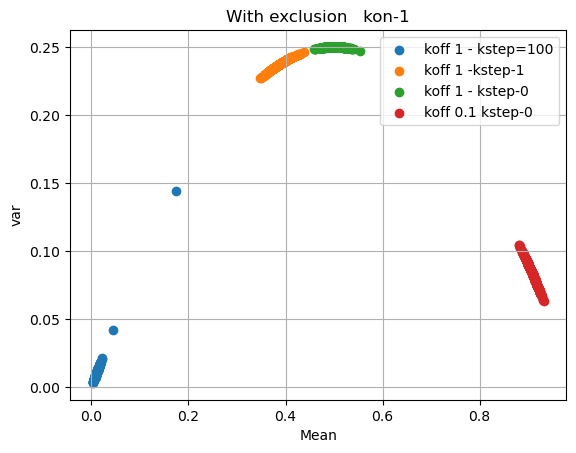

In [44]:
plt.scatter(mean2, var2, label = "koff 1 - kstep=100")
plt.scatter(mean, var, label="koff 1 -kstep-1")
plt.scatter(mean3, var3, label = "koff 1 - kstep-0")
plt.scatter(mean4, var4, label = "koff 0.1 kstep-0")
plt.legend()
plt.title("With exclusion   kon-1")
plt.xlabel("Mean")
plt.ylabel("var")
plt.grid()
plt.savefig("var_mean.png")

In [338]:
@njit
def mean_var(L, T, kon, koff, kstep):
    data, times = simulation(L, T, kon, koff, kstep)
    tot_kinesins = np.sum(data, axis=1)
    return tot_kinesins[-1]

In [343]:
@njit(parallel=True)
def calc_ratio_kon(L, T, kon_list:np.ndarray, kstep): # Assemble average only
    res = np.zeros(len(kon_list))
    # print(res)
    for i in prange(len(kon_list)):
        res[i] = mean_var(L, T, kon_list[i], 1, kstep)
    return res

In [345]:
A = calc_ratio_kon(L, T, kon_list, kstep)

In [348]:
@njit(parallel=True)
def assemble(SAMPLES, L, T, kon_list, kstep):
    RES = np.zeros((SAMPLES, len(kon_list)))
    for sample in prange(SAMPLES):
        RES[sample, :] = calc_ratio_kon(L, T, kon_list, kstep)[:]
    return RES

# kstep = 0

In [89]:
SAMPLES = 1000
RES = np.zeros((SAMPLES, len(kon_list), 2))
for sample in range(SAMPLES):
    A = calc_ratio_kon(300, 20, kon_list, 0)
    RES[sample, :, 0] = A[:, 0]
    RES[sample, :, 1] = A[:, 1]


In [90]:
res = RES[:,:,0]

In [ ]:
# with open('./mean_var_zero_kstep_with_exclusion', 'wb') as f:
#     pickle.dump(res, f)

In [4]:
kon_list = np.logspace(-4,2, 60)

In [2]:
with open('./mean_var_zero_kstep_with_exclusion', 'rb') as f:
    res = pickle.load(f)

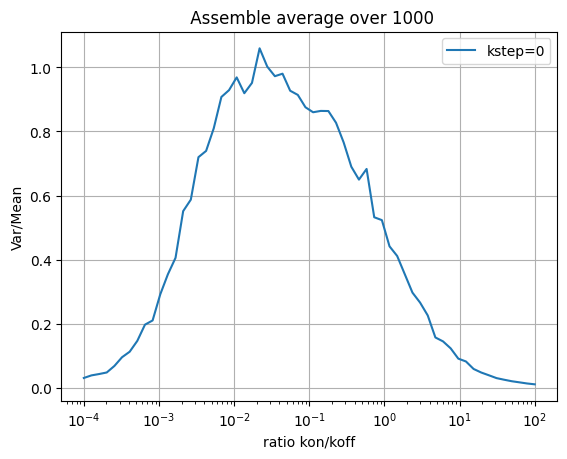

In [5]:
fig, (ax1) = plt.subplots(1,1)
ax1.semilogx(kon_list, np.var(res[:,:], axis=0)/np.mean(res[:,:], axis=0), label = "kstep=0")
ax1.set(
    title = " Assemble average over 1000",
    xlabel = "ratio kon/koff",
    ylabel = "Var/Mean"
)
ax1.grid()
ax1.legend()


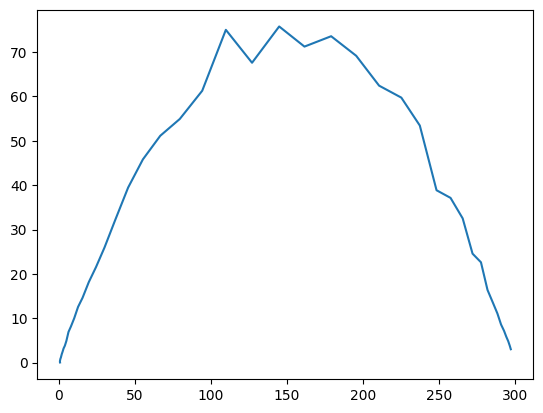

In [14]:
plt.plot(np.mean(res[:,:], axis=0),np.var(res[:,:], axis=0))

# kstep =10

In [353]:
total = assemble(1000, L, 20, kon_list, 10)

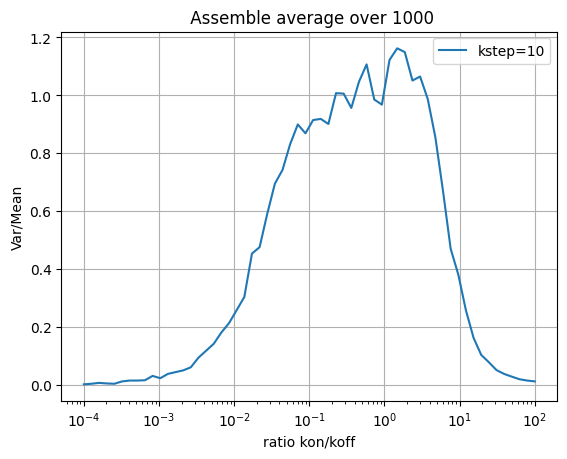

In [11]:
fig, (ax1) = plt.subplots(1,1)
ax1.semilogx(kon_list, np.var(total[:,:], axis=0)/np.mean(total[:,:], axis=0), label = "kstep=10")
ax1.set(
    title = " Assemble average over 1000",
    xlabel = "ratio kon/koff",
    ylabel = "Var/Mean"
)
ax1.grid()
ax1.legend()


In [356]:
# with open('./mean_var_high_kstep_with_exclusion', 'wb') as f:
#     pickle.dump(total, f)

In [9]:
with open('./mean_var_high_kstep_with_exclusion', 'rb') as f:
    total = pickle.load(f)

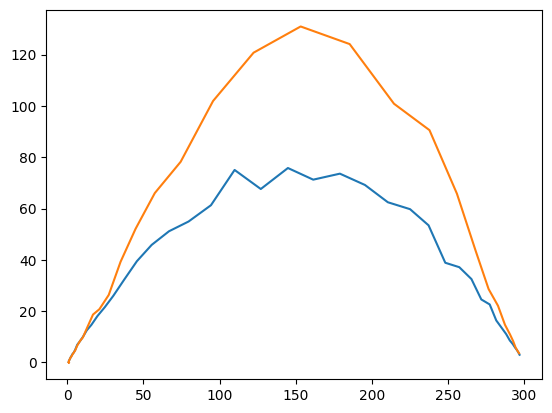

In [17]:
plt.plot(np.mean(res[:,:], axis=0),np.var(res[:,:], axis=0))
plt.plot(np.mean(total[:,:], axis=0),np.var(total[:,:], axis=0))

1) Var/Mean over x for differe
2) var o ver mean fro differe ksteps. Plot the pick. Does the pick shift?